
# GAIA Claude Native Trace Analysis

This notebook parses the `normalized_trace.json` files produced by `run_claude_task_native.py` and analyzes whether **semantic similarity of prompts** correlates with **similarity of execution traces**.

It is designed for the current folder structure:

```text
results/claude_native/
  gaia_level1_shard_00/
    <task_id>/
      normalized_trace.json
      structured_output.json
  gaia_level1_shard_01/
  ...
```

In [2]:

from pathlib import Path
import json
import math
import warnings
from collections import Counter, defaultdict
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances

warnings.filterwarnings("ignore")

# --------------------------
# Project path configuration
# --------------------------
from pathlib import Path
import json
from collections import Counter
import numpy as np
import pandas as pd

DEFAULT_PROJECT_ROOT = Path("/home/tungichen_umass_edu/ekb-claude")
PROJECT_ROOT = DEFAULT_PROJECT_ROOT if DEFAULT_PROJECT_ROOT.exists() else Path.cwd().resolve()

RESULTS_ROOT = PROJECT_ROOT / "results" / "claude_native"
OUTPUT_DIR = PROJECT_ROOT / "results" / "analysis" / "gaia_claude_native"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def iter_normalized_trace_paths(results_root: Path):
    if not results_root.exists():
        raise FileNotFoundError(f"Trace root does not exist: {results_root}")
    for path in sorted(results_root.glob("gaia_level1_shard_*/*/normalized_trace.json")):
        yield path

def canonical_tool_name(tool):
    if tool is None:
        return "unknown"
    tool = str(tool).strip()
    mapping = {
        "WebSearch": "WebSearch",
        "WebFetch": "WebFetch",
        "Bash": "Bash",
        "Read": "Read",
        "Write": "Write",
        "Edit": "Edit",
        "Grep": "Grep",
        "Glob": "Glob",
        "ToolSearch": "ToolSearch",
        "StructuredOutput": "StructuredOutput",
    }
    return mapping.get(tool, tool)

def extract_steps(trace: dict):
    steps = trace.get("steps", [])
    if not isinstance(steps, list):
        return []

    out = []
    for s in steps:
        if not isinstance(s, dict):
            continue
        out.append({
            "step": s.get("step"),
            "tool": canonical_tool_name(s.get("tool")),
            "status": s.get("status"),
            "latency_ms": s.get("latency_ms"),
        })
    return out

def safe_num(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default

def build_trace_record(path: Path):
    trace = load_json(path)
    steps = extract_steps(trace)

    tools_all = [s["tool"] for s in steps]
    tool_counts = Counter(tools_all)

    record = {
        "query_id": trace.get("query_id"),
        "query_text": trace.get("query_text", ""),
        "benchmark": trace.get("benchmark"),
        "split": trace.get("split"),
        "level": trace.get("level"),
        "agent": trace.get("agent"),
        "model_requested": trace.get("model_requested"),
        "effort": trace.get("effort"),

        # scalar execution attributes
        "total_tool_calls": int(trace.get("total_tool_calls", len(steps) or 0)),
        "total_latency_ms": safe_num(trace.get("total_latency_ms")),
        "total_tokens": safe_num(trace.get("total_tokens")),

        # sequence / set views
        "tool_sequence_all": tools_all,
        "tools_used": sorted(set(tools_all)),

        # bookkeeping
        "normalized_trace_path": str(path),
        "task_dir": str(path.parent),
        "shard_name": path.parent.parent.name,

        # keep raw tool counts temporarily for dense expansion later
        "_tool_counts": dict(tool_counts),
    }
    return record

# ------------------------------------------------------------
# Load traces
# ------------------------------------------------------------
trace_records = [build_trace_record(p) for p in iter_normalized_trace_paths(RESULTS_ROOT)]
df = pd.DataFrame(trace_records)

print(f"Loaded {len(df)} normalized traces.")

# ------------------------------------------------------------
# Expand dense tool_count__* columns with zeros instead of NaN
# ------------------------------------------------------------
all_tools = sorted({
    tool
    for record in trace_records
    for tool in record["_tool_counts"].keys()
})

for tool in all_tools:
    col = f"tool_count__{tool}"
    df[col] = df["_tool_counts"].apply(lambda d: int(d.get(tool, 0)))

df = df.drop(columns=["_tool_counts"])

# Ensure scalar columns are numeric
for c in ["total_tool_calls", "total_latency_ms", "total_tokens"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Optional sanity fill
df["total_tool_calls"] = df["total_tool_calls"].fillna(0).astype(int)
df["total_latency_ms"] = df["total_latency_ms"].fillna(0.0)
df["total_tokens"] = df["total_tokens"].fillna(0.0)

# Show only the columns that matter for later analysis
tool_count_cols = sorted([c for c in df.columns if c.startswith("tool_count__")])

display_cols = [
    "query_id",
    "query_text",
    "total_tool_calls",
    "total_latency_ms",
    "total_tokens",
    "tool_sequence_all",
    "tools_used",
] + tool_count_cols

display(df[display_cols].head(5))

print("Observed tools:", all_tools)
print("Tool-count columns:", tool_count_cols)


Loaded 51 normalized traces.


,query_id,query_text,total_tool_calls,total_latency_ms,total_tokens,tool_sequence_all,tools_used,tool_count__Bash,tool_count__Glob,tool_count__Read,tool_count__StructuredOutput,tool_count__ToolSearch,tool_count__WebFetch,tool_count__WebSearch
0,23dd907f-1261-4488-b21c-e9185af91d5e,In Audre Lorde’s poem “Father Son and Holy Gho...,10,61077.0,219821.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSe...",0,0,0,1,2,6,1
1,3f57289b-8c60-48be-bd80-01f8099ca449,How many at bats did the Yankee with the most ...,6,27305.0,134850.0,"[ToolSearch, WebSearch, ToolSearch, WebFetch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSe...",0,0,0,1,2,2,1
2,46719c30-f4c3-4cad-be07-d5cb21eee6bb,Of the authors (First M. Last) that worked on ...,12,87554.0,260497.0,"[ToolSearch, WebSearch, WebSearch, WebSearch, ...","[StructuredOutput, ToolSearch, WebFetch, WebSe...",0,0,0,1,2,6,3
3,50ec8903-b81f-4257-9450-1085afd2c319,A standard Rubik’s cube has been broken into c...,1,60844.0,45002.0,[StructuredOutput],[StructuredOutput],0,0,0,1,0,0,0
4,5cfb274c-0207-4aa7-9575-6ac0bd95d9b2,Each cell in the attached spreadsheet represen...,10,34699.0,225857.0,"[Bash, Bash, Bash, Bash, Bash, Bash, Bash, Bas...","[Bash, StructuredOutput]",9,0,0,1,0,0,0


Observed tools: ['Bash', 'Glob', 'Read', 'StructuredOutput', 'ToolSearch', 'WebFetch', 'WebSearch']
Tool-count columns: ['tool_count__Bash', 'tool_count__Glob', 'tool_count__Read', 'tool_count__StructuredOutput', 'tool_count__ToolSearch', 'tool_count__WebFetch', 'tool_count__WebSearch']


In [34]:
# ============================================================
# Compute final-answer accuracy from normalized_trace.json files
# ============================================================

from pathlib import Path
from collections import Counter
import json
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def iter_normalized_trace_paths(results_root: Path):
    if not results_root.exists():
        raise FileNotFoundError(f"Trace root does not exist: {results_root}")
    for path in sorted(results_root.glob("gaia_level1_shard_*/*/normalized_trace.json")):
        yield path

def normalize_answer(x):
    if x is None:
        return None
    x = str(x).strip()
    if x == "":
        return ""
    return x.casefold()

# ------------------------------------------------------------
# Load answer-level evaluation fields
# ------------------------------------------------------------
answer_records = []

for path in iter_normalized_trace_paths(RESULTS_ROOT):
    trace = load_json(path)

    pred = trace.get("final_answer_pred")
    gt = trace.get("ground_truth_answer")
    exact = trace.get("exact_match")

    # Fallback if exact_match is missing
    if exact is None:
        pred_norm = normalize_answer(pred)
        gt_norm = normalize_answer(gt)
        exact = (pred_norm == gt_norm) if (pred_norm is not None and gt_norm is not None) else False

    answer_records.append({
        "query_id": trace.get("query_id"),
        "query_text": trace.get("query_text", ""),
        "shard_name": path.parent.parent.name,
        "final_answer_pred": pred,
        "ground_truth_answer": gt,
        "exact_match": bool(exact),
        "success": trace.get("success"),
        "normalized_trace_path": str(path),
    })

df_acc = pd.DataFrame(answer_records)

if len(df_acc) == 0:
    raise ValueError("No normalized_trace.json files were found.")

# ------------------------------------------------------------
# Overall accuracy
# ------------------------------------------------------------
n_total = len(df_acc)
n_correct = int(df_acc["exact_match"].sum())
acc = n_correct / n_total

print(f"Loaded {n_total} traces")
print(f"Correct: {n_correct}")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ------------------------------------------------------------
# Optional: per-shard accuracy
# ------------------------------------------------------------
df_shard_acc = (
    df_acc.groupby("shard_name", as_index=False)
    .agg(
        n=("query_id", "count"),
        correct=("exact_match", "sum"),
    )
)
df_shard_acc["accuracy"] = df_shard_acc["correct"] / df_shard_acc["n"]

print("\nPer-shard accuracy:")
display(df_shard_acc.sort_values("shard_name").reset_index(drop=True))

# ------------------------------------------------------------
# Optional: inspect incorrect cases
# ------------------------------------------------------------
df_wrong = df_acc.loc[~df_acc["exact_match"], [
    "query_id",
    "query_text",
    "final_answer_pred",
    "ground_truth_answer",
    "shard_name",
]]

print(f"\nNumber of incorrect cases: {len(df_wrong)}")
display(df_wrong.reset_index(drop=True))

Loaded 51 traces
Correct: 30
Accuracy: 0.5882 (58.82%)

Per-shard accuracy:


,shard_name,n,correct,accuracy
0,gaia_level1_shard_00,14,8,0.571429
1,gaia_level1_shard_01,11,8,0.727273
2,gaia_level1_shard_02,13,6,0.461538
3,gaia_level1_shard_03,13,8,0.615385



Number of incorrect cases: 21


,query_id,query_text,final_answer_pred,ground_truth_answer,shard_name
0,46719c30-f4c3-4cad-be07-d5cb21eee6bb,Of the authors (First M. Last) that worked on ...,NaN,Mapping Human Oriented Information to Software...,gaia_level1_shard_00
1,65afbc8a-89ca-4ad5-8d62-355bb401f61d,You are given this Excel file as a map. You st...,NaN,F478A7,gaia_level1_shard_00
2,7bd855d8-463d-4ed5-93ca-5fe35145f733,The attached Excel file contains the sales of ...,NaN,89706.00,gaia_level1_shard_00
3,9318445f-fe6a-4e1b-acbf-c68228c9906a,"As a comma separated list with no whitespace, ...",NaN,"3/4,1/4,3/4,3/4,2/4,1/2,5/35,7/21,30/5,30/5,3/...",gaia_level1_shard_00
4,a0068077-79f4-461a-adfe-75c1a4148545,What was the actual enrollment count of the cl...,NaN,90,gaia_level1_shard_00
5,e142056d-56ab-4352-b091-b56054bd1359,"Bob was invited to participate in a game show,...","$12,000",16000,gaia_level1_shard_00
6,0383a3ee-47a7-41a4-b493-519bdefe0488,On the BBC Earth YouTube video of the Top 5 Si...,Penguin,Rockhopper penguin,gaia_level1_shard_01
7,a3fbeb63-0e8c-4a11-bff6-0e3b484c3e9c,How many slides in this PowerPoint presentatio...,NaN,4,gaia_level1_shard_01
8,cabe07ed-9eca-40ea-8ead-410ef5e83f91,What is the surname of the equine veterinarian...,NaN,Louvrier,gaia_level1_shard_01
9,1f975693-876d-457b-a649-393859e79bf3,"Hi, I was out sick from my classes on Friday, ...",NaN,"132, 133, 134, 197, 245",gaia_level1_shard_02


,tool,count
0,WebFetch,104
1,Bash,72
2,WebSearch,60
3,ToolSearch,58
4,StructuredOutput,40
5,Glob,6
6,Read,1


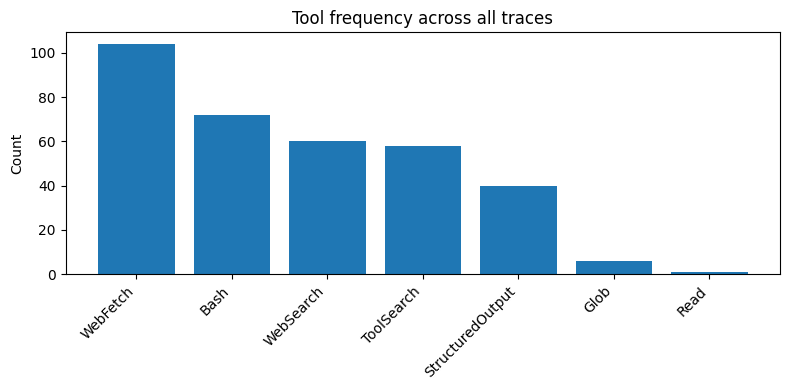

In [4]:

# Tool frequency summary
tool_counter = Counter()
for tools in df["tool_sequence_all"]:
    tool_counter.update(tools)

tool_freq_df = pd.DataFrame(
    [{"tool": k, "count": v} for k, v in sorted(tool_counter.items(), key=lambda x: (-x[1], x[0]))]
)
display(tool_freq_df)

plt.figure(figsize=(8, 4))
plt.bar(tool_freq_df["tool"], tool_freq_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Tool frequency across all traces")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


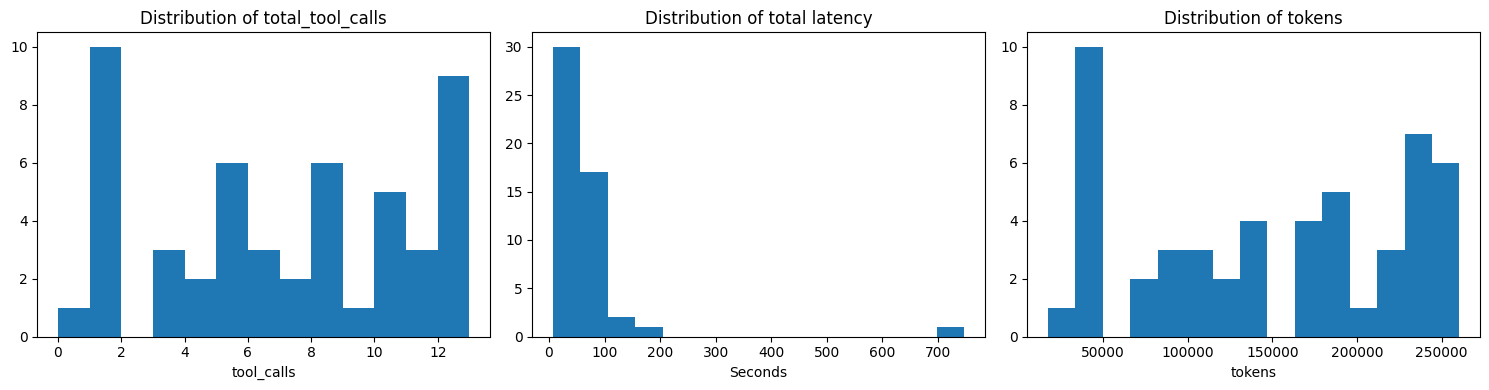

In [5]:

# Basic distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["total_tool_calls"], bins=min(15, max(5, df["total_tool_calls"].nunique())))
axes[0].set_title("Distribution of total_tool_calls")
axes[0].set_xlabel("tool_calls")

axes[1].hist(df["total_latency_ms"].dropna() / 1000.0, bins=15)
axes[1].set_title("Distribution of total latency")
axes[1].set_xlabel("Seconds")

# axes[2].hist(np.log1p(df["total_tokens"].dropna()), bins=15)
axes[2].hist(df["total_tokens"].dropna(), bins=15)
axes[2].set_title("Distribution of tokens")
axes[2].set_xlabel("tokens")

plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# Execution feature views
#   1) scalar attributes
#   2) tool-count vector
#   3) tool-sequence structure
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# Basic normalization helpers
# ------------------------------------------------------------
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

def normalize_tool_token(t):
    if t is None:
        return "UNKNOWN"
    return str(t).strip()

# ------------------------------------------------------------
# Normalize sequence / set columns
# ------------------------------------------------------------
df["tool_sequence_all"] = df["tool_sequence_all"].apply(
    lambda seq: [normalize_tool_token(t) for t in ensure_list(seq)]
)

# If tools_used_core exists, use it; otherwise fall back to tools_used
if "tools_used_core" in df.columns:
    df["tools_used"] = df["tools_used_core"].apply(
        lambda xs: [normalize_tool_token(x) for x in ensure_list(xs)]
    )
else:
    df["tools_used"] = df["tools_used"].apply(
        lambda xs: [normalize_tool_token(x) for x in ensure_list(xs)]
    )

# ------------------------------------------------------------
# 1) Scalar execution attributes
# ------------------------------------------------------------
scalar_cols = [
    "total_tool_calls",
    "total_latency_ms",
    "total_tokens",
]

scalar_df = df[scalar_cols].copy()
for c in scalar_cols:
    scalar_df[c] = pd.to_numeric(scalar_df[c], errors="coerce")

scalar_df = scalar_df.fillna(0.0)

print("Scalar execution attributes")
display(scalar_df.head(10))

# ------------------------------------------------------------
# 2) Tool-count vector
# ------------------------------------------------------------
tool_count_cols = sorted([c for c in df.columns if c.startswith("tool_count__")])

tool_count_df = df[tool_count_cols].copy()
for c in tool_count_cols:
    tool_count_df[c] = pd.to_numeric(tool_count_df[c], errors="coerce")

tool_count_df = tool_count_df.fillna(0.0)

# print("Tool-count vector columns")
# print(tool_count_cols)
# display(tool_count_df.head(10))

# # Numeric matrix for cosine-based similarity
# X_tool_count = tool_count_df.values.astype(float)

# print("Tool-count matrix shape:", X_tool_count.shape)

# ------------------------------------------------------------
# 3) Tool-sequence structure
# ------------------------------------------------------------
seq_obs_df = df[["query_text", "tool_sequence_all"]].copy()
seq_obs_df["tool_sequence_str"] = seq_obs_df["tool_sequence_all"].apply(lambda seq: " -> ".join(seq))

# print("Tool sequence examples")
# display(seq_obs_df[["tool_sequence_str"]].head(15))

# Also inspect common exact sequences
seq_freq_df = (
    seq_obs_df["tool_sequence_str"]
    .value_counts()
    .rename_axis("tool_sequence_str")
    .reset_index(name="count")
)

print("Most common tool sequences")
display(seq_freq_df.head(40))

# Tool-set membership as a separate diagnostic attribute
tool_set_obs_df = df[["query_text", "tools_used"]].copy()
tool_set_obs_df["tool_set_str"] = tool_set_obs_df["tools_used"].apply(lambda xs: ", ".join(sorted(set(xs))))


Scalar execution attributes


,total_tool_calls,total_latency_ms,total_tokens
0,10,61077.0,219821.0
1,6,27305.0,134850.0
2,12,87554.0,260497.0
3,1,60844.0,45002.0
4,10,34699.0,225857.0
5,11,45939.0,228437.0
6,10,56938.0,205647.0
7,10,109000.0,235801.0
8,13,60164.0,239707.0
9,11,52185.0,233978.0


Most common tool sequences


,tool_sequence_str,count
0,StructuredOutput,10
1,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,4
2,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,2
3,ToolSearch -> WebSearch -> StructuredOutput,2
4,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,2
5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,1
6,ToolSearch -> WebSearch -> WebSearch -> WebSea...,1
7,Bash -> Bash -> Bash -> Bash -> Bash -> Bash -...,1
8,Bash -> Bash -> Bash -> Bash -> Bash -> Bash -...,1
9,ToolSearch -> WebFetch -> WebFetch -> WebSearc...,1



## Build embedding matrix for prompt semantics

Preferred backend: `sentence-transformers/all-MiniLM-L6-v2`.


In [6]:

# Prompt embedding backend with fallback
EMBEDDING_BACKEND = None

def make_embeddings(texts):
    global EMBEDDING_BACKEND
    texts = [str(t) for t in texts]

    try:
        from sentence_transformers import SentenceTransformer
        model_name = "sentence-transformers/all-MiniLM-L6-v2"
        model = SentenceTransformer(model_name)
        X = model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
        EMBEDDING_BACKEND = model_name
        return np.asarray(X, dtype=np.float32)
    except Exception as e:
        print("SentenceTransformer unavailable; falling back to TF-IDF + SVD")
        print("Reason:", repr(e))
        vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X_tfidf = vectorizer.fit_transform(texts)
        n_components = min(128, max(2, X_tfidf.shape[1] - 1))
        svd = TruncatedSVD(n_components=n_components, random_state=42)
        X = svd.fit_transform(X_tfidf)
        # normalize rows so cosine similarity behaves sensibly
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        X = X / norms
        EMBEDDING_BACKEND = "tfidf+svd"
        return np.asarray(X, dtype=np.float32)

X_embed = make_embeddings(df["query_text"].tolist())
print("Embedding backend:", EMBEDDING_BACKEND)
print("Embedding shape:", X_embed.shape)


Batches: 100%|██████████| 2/2 [00:00<00:00,  9.69it/s]

Embedding backend: sentence-transformers/all-MiniLM-L6-v2
Embedding shape: (51, 384)


In [7]:
# ============================================================
# Cluster prompts by semantic embedding for manual inspection
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from IPython.display import display

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
# You can set this manually, e.g. 4, 6, 8, ...
# If None, we will pick the best value by silhouette score.
N_CLUSTERS = 8

# Search range used only when N_CLUSTERS is None
MIN_CLUSTERS = 4
MAX_CLUSTERS = min(6, len(df) - 1)

# ------------------------------------------------------------
# Choose number of clusters
# ------------------------------------------------------------
if len(df) < 2:
    raise ValueError("Need at least 2 traces to perform clustering.")

if N_CLUSTERS is None:
    candidate_scores = []
    for k in range(MIN_CLUSTERS, MAX_CLUSTERS + 1):
        try:
            model = AgglomerativeClustering(
                n_clusters=k,
                metric="cosine",
                linkage="average",
            )
            labels = model.fit_predict(X_embed)
            # silhouette with cosine distance
            score = silhouette_score(X_embed, labels, metric="cosine")
            candidate_scores.append((k, score))
        except Exception as e:
            print(f"Skipping k={k} due to error: {e}")

    if not candidate_scores:
        raise RuntimeError("Failed to compute any valid clustering candidates.")

    candidate_df = pd.DataFrame(candidate_scores, columns=["n_clusters", "silhouette_score"])
    display(candidate_df.sort_values("n_clusters"))

    best_row = candidate_df.sort_values("silhouette_score", ascending=False).iloc[0]
    best_k = int(best_row["n_clusters"])
    print(f"Selected n_clusters={best_k} by highest silhouette score.")
else:
    best_k = int(N_CLUSTERS)
    print(f"Using manually specified n_clusters={best_k}")

# ------------------------------------------------------------
# Fit final clustering model
# ------------------------------------------------------------
cluster_model = AgglomerativeClustering(
    n_clusters=best_k,
    metric="cosine",
    linkage="average",
)
cluster_labels = cluster_model.fit_predict(X_embed)

df["semantic_cluster"] = cluster_labels

# ------------------------------------------------------------
# Build readable inspection table
# ------------------------------------------------------------
inspect_df = df[
    [
        "query_id",
        "query_text",
        "semantic_cluster",
        "total_tool_calls",
        "tool_sequence_all",
        "tools_used",
    ]
].copy()

def to_seq_str(x):
    if isinstance(x, list):
        return " -> ".join(str(v) for v in x)
    if pd.isna(x):
        return ""
    return str(x)

def to_set_str(x):
    if isinstance(x, list):
        return ", ".join(sorted(str(v) for v in x))
    if pd.isna(x):
        return ""
    return str(x)

inspect_df["tool_sequence_str"] = inspect_df["tool_sequence_all"].apply(to_seq_str)
inspect_df["tools_used_str"] = inspect_df["tools_used"].apply(to_set_str)

cluster_size_df = (
    inspect_df.groupby("semantic_cluster")
    .size()
    .reset_index(name="cluster_size")
    .sort_values(["cluster_size", "semantic_cluster"], ascending=[False, True])
)

print("Cluster sizes")
display(cluster_size_df)

# ------------------------------------------------------------
# Print each cluster as a separate table for manual observation
# ------------------------------------------------------------
for cluster_id in sorted(inspect_df["semantic_cluster"].unique()):
    sub = inspect_df[inspect_df["semantic_cluster"] == cluster_id].copy()

    # Sort for easier reading
    sub = sub.sort_values(
        by=["total_tool_calls", "query_text"],
        ascending=[True, True]
    )

    print("=" * 120)
    print(f"Semantic cluster {cluster_id} | size = {len(sub)}")

    display(
        sub[
            [
                "query_id",
                "query_text",
                "total_tool_calls",
                "tool_sequence_str",
                "tools_used_str",
            ]
        ].reset_index(drop=True)
    )

Using manually specified n_clusters=8
Cluster sizes


,semantic_cluster,cluster_size
0,0,19
2,2,12
3,3,7
6,6,4
1,1,3
4,4,3
7,7,2
5,5,1


Semantic cluster 0 | size = 19


,query_id,query_text,total_tool_calls,tool_sequence_str,tools_used_str
0,2d83110e-a098-4ebb-9987-066c06fa42d0,".rewsna eht sa ""tfel"" drow eht fo etisoppo eht...",0,,
1,50ad0280-0819-4bd9-b275-5de32d3b5bcb,Pull out the sentence in the following 5x7 blo...,1,StructuredOutput,StructuredOutput
2,bda648d7-d618-4883-88f4-3466eabd860e,Where were the Vietnamese specimens described ...,3,ToolSearch -> WebSearch -> StructuredOutput,"StructuredOutput, ToolSearch, WebSearch"
3,4fc2f1ae-8625-45b5-ab34-ad4433bc21f8,Who nominated the only Featured Article on Eng...,4,ToolSearch -> WebFetch -> WebFetch -> Structur...,"StructuredOutput, ToolSearch, WebFetch"
4,8e867cd7-cff9-4e6c-867a-ff5ddc2550be,How many studio albums were published by Merce...,5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
5,b816bfce-3d80-4913-a07d-69b752ce6377,In Emily Midkiff's June 2014 article in a jour...,5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
6,5188369a-3bbe-43d8-8b94-11558f909a08,What writer is quoted by Merriam-Webster for t...,5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
7,7d4a7d1d-cac6-44a8-96e8-ea9584a70825,"According to Girls Who Code, how long did it t...",7,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
8,840bfca7-4f7b-481a-8794-c560c340185d,"On June 6, 2023, an article by Carolyn Collins...",7,ToolSearch -> WebSearch -> WebFetch -> WebFetc...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
9,0383a3ee-47a7-41a4-b493-519bdefe0488,On the BBC Earth YouTube video of the Top 5 Si...,8,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"


Semantic cluster 1 | size = 3


...

,query_id,query_text,total_tool_calls,tool_sequence_str,tools_used_str
0,b415aba4-4b68-4fc6-9b89-2c812e55a3e1,In Nature journal's Scientific Reports confere...,13,ToolSearch -> WebSearch -> WebSearch -> ToolSe...,"ToolSearch, WebFetch, WebSearch"


Semantic cluster 6 | size = 4


,query_id,query_text,total_tool_calls,tool_sequence_str,tools_used_str
0,cf106601-ab4f-4af9-b045-5295fe67b37d,What country had the least number of athletes ...,5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
1,3f57289b-8c60-48be-bd80-01f8099ca449,How many at bats did the Yankee with the most ...,6,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
2,5a0c1adf-205e-4841-a666-7c3ef95def9d,What is the first name of the only Malko Compe...,6,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
3,a0c07678-e491-4bbc-8f0b-07405144218f,Who are the pitchers with the number before an...,8,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"


Semantic cluster 7 | size = 2


,query_id,query_text,total_tool_calls,tool_sequence_str,tools_used_str
0,6f37996b-2ac7-44b0-8e68-6d28256631b4,"Given this table defining * on the set S = {a,...",1,StructuredOutput,StructuredOutput
1,27d5d136-8563-469e-92bf-fd103c28b57c,¬(A ∧ B) ↔ (¬A ∨ ¬B)\n¬(A ∨ B) ↔ (¬A ∧ ¬B)\n(A...,1,StructuredOutput,StructuredOutput


In [14]:
# ============================================================
# Top-3 nearest semantic neighbors per prompt
# Greedy non-overlapping group selection:
# once a prompt is printed in one group, it cannot appear again
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_cols = ["query_id", "query_text", "total_tool_calls", "tool_sequence_all", "tools_used"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

n = len(df)
if n < 4:
    raise ValueError("Need at least 4 prompts to build anchor + top-3-neighbor neighborhoods.")

TOP_K_GROUPS = 5  # reduced as requested

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

def seq_to_str(x):
    xs = as_list(x)
    return " -> ".join(str(v) for v in xs)

def tools_to_str(x):
    xs = as_list(x)
    return ", ".join(str(v) for v in xs)

# ------------------------------------------------------------
# Cosine similarity / distance in prompt embedding space
# ------------------------------------------------------------
S_sem = cosine_similarity(X_embed)
D_sem = 1.0 - S_sem   # cosine distance

# ------------------------------------------------------------
# Build candidate groups for every anchor
# Each group = [anchor, nearest_1, nearest_2, nearest_3]
# Score = average pairwise cosine distance within the 4-prompt group
# ------------------------------------------------------------
candidate_groups = []

for i in range(n):
    order = np.argsort(D_sem[i])
    order = [j for j in order if j != i]

    top3 = order[:3]
    if len(top3) < 3:
        continue

    group = [i] + top3

    pairwise_dists = [
        float(D_sem[group[a], group[b]])
        for a in range(len(group))
        for b in range(a + 1, len(group))
    ]
    avg_pairwise_dist = float(np.mean(pairwise_dists)) if pairwise_dists else np.nan

    candidate_groups.append({
        "anchor_idx": i,
        "group_indices": group,
        "anchor_query_id": df.iloc[i]["query_id"],
        "anchor_query_text": df.iloc[i]["query_text"],
        "neighbor_indices": top3,
        "avg_pairwise_cosine_distance": avg_pairwise_dist,
        "anchor_to_n1_dist": float(D_sem[i, top3[0]]),
        "anchor_to_n2_dist": float(D_sem[i, top3[1]]),
        "anchor_to_n3_dist": float(D_sem[i, top3[2]]),
    })

candidate_groups_df = pd.DataFrame(candidate_groups).sort_values(
    by="avg_pairwise_cosine_distance",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# Greedy selection of NON-OVERLAPPING groups
# Once a prompt has been used in a printed group, it cannot appear again
# ------------------------------------------------------------
selected_groups = []
used_prompt_indices = set()

for _, row in candidate_groups_df.iterrows():
    group_indices = list(row["group_indices"])

    # skip if any prompt in this group was already used
    if any(idx in used_prompt_indices for idx in group_indices):
        continue

    selected_groups.append(row.to_dict())
    used_prompt_indices.update(group_indices)

    if len(selected_groups) >= TOP_K_GROUPS:
        break

selected_groups_df = pd.DataFrame(selected_groups).reset_index(drop=True)

print("Top non-overlapping semantic neighborhoods ranked by average pairwise cosine distance")
display(
    selected_groups_df[
        [
            "anchor_query_id",
            "avg_pairwise_cosine_distance",
            "anchor_to_n1_dist",
            "anchor_to_n2_dist",
            "anchor_to_n3_dist",
        ]
    ]
)

# ------------------------------------------------------------
# Print the selected groups for manual observation
# ------------------------------------------------------------
for rank, row in selected_groups_df.iterrows():
    anchor_idx = int(row["anchor_idx"])
    neighbor_indices = list(row["neighbor_indices"])
    group_indices = [anchor_idx] + neighbor_indices

    sub = df.iloc[group_indices][
        ["query_id", "query_text", "total_tool_calls", "tool_sequence_all", "tools_used"]
    ].copy()

    sub["role"] = ["anchor", "neighbor_1", "neighbor_2", "neighbor_3"]
    sub["tool_sequence_str"] = sub["tool_sequence_all"].apply(seq_to_str)
    sub["tools_used_str"] = sub["tools_used"].apply(tools_to_str)

    dist_to_anchor = [0.0] + [float(D_sem[anchor_idx, j]) for j in neighbor_indices]
    sub["cosine_distance_to_anchor"] = dist_to_anchor

    sub = sub[
        [
            "role",
            "query_id",
            "query_text",
            "cosine_distance_to_anchor",
            "total_tool_calls",
            "tool_sequence_str",
            "tools_used_str",
        ]
    ].reset_index(drop=True)

    print("=" * 140)
    print(
        f"Rank {rank + 1} | "
        f"avg_pairwise_cosine_distance = {row['avg_pairwise_cosine_distance']:.4f}"
    )
    display(sub)

# print(f"Selected {len(selected_groups_df)} non-overlapping groups "
#       f"covering {len(used_prompt_indices)} unique prompts out of {n} total prompts.")

Top non-overlapping semantic neighborhoods ranked by average pairwise cosine distance


,anchor_query_id,avg_pairwise_cosine_distance,anchor_to_n1_dist,anchor_to_n2_dist,anchor_to_n3_dist
0,3cef3a44-215e-4aed-8e3b-b1e3f08063b7,0.660492,0.613446,0.679495,0.696158
1,935e2cff-ae78-4218-b3f5-115589b19dae,0.683480,0.611050,0.629653,0.648806
2,0383a3ee-47a7-41a4-b493-519bdefe0488,0.706712,0.609438,0.617041,0.758443
3,65afbc8a-89ca-4ad5-8d62-355bb401f61d,0.740641,0.553883,0.638357,0.642401
4,cf106601-ab4f-4af9-b045-5295fe67b37d,0.761530,0.693405,0.711403,0.721846


Rank 1 | avg_pairwise_cosine_distance = 0.6605


,role,query_id,query_text,cosine_distance_to_anchor,total_tool_calls,tool_sequence_str,tools_used_str
0,anchor,3cef3a44-215e-4aed-8e3b-b1e3f08063b7,"I'm making a grocery list for my mom, but she'...",0.000000,1,StructuredOutput,StructuredOutput
1,neighbor_1,99c9cc74-fdc8-46c6-8f8d-3ce2d3bfeea3,"Hi, I'm making a pie but I could use some help...",0.613446,9,Bash -> Bash -> Bash -> ToolSearch -> WebSearc...,"Bash, StructuredOutput, ToolSearch, WebFetch, ..."
2,neighbor_2,dc28cf18-6431-458b-83ef-64b3ce566c10,"My family reunion is this week, and I was assi...",0.679495,1,StructuredOutput,StructuredOutput
3,neighbor_3,7bd855d8-463d-4ed5-93ca-5fe35145f733,The attached Excel file contains the sales of ...,0.696158,13,Glob -> Glob -> Bash -> Bash -> Bash -> Bash -...,"Bash, Glob, StructuredOutput, ToolSearch, WebF..."


Rank 2 | avg_pairwise_cosine_distance = 0.6835


...

,role,query_id,query_text,cosine_distance_to_anchor,total_tool_calls,tool_sequence_str,tools_used_str
0,anchor,0383a3ee-47a7-41a4-b493-519bdefe0488,On the BBC Earth YouTube video of the Top 5 Si...,0.000000,8,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
1,neighbor_1,a3fbeb63-0e8c-4a11-bff6-0e3b484c3e9c,How many slides in this PowerPoint presentatio...,0.609438,12,Bash -> Glob -> Glob -> Bash -> Bash -> Bash -...,"Bash, Glob, ToolSearch, WebFetch"
2,neighbor_2,4fc2f1ae-8625-45b5-ab34-ad4433bc21f8,Who nominated the only Featured Article on Eng...,0.617041,4,ToolSearch -> WebFetch -> WebFetch -> Structur...,"StructuredOutput, ToolSearch, WebFetch"
3,neighbor_3,cabe07ed-9eca-40ea-8ead-410ef5e83f91,What is the surname of the equine veterinarian...,0.758443,13,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"ToolSearch, WebFetch, WebSearch"


Rank 4 | avg_pairwise_cosine_distance = 0.7406


,role,query_id,query_text,cosine_distance_to_anchor,total_tool_calls,tool_sequence_str,tools_used_str
0,anchor,65afbc8a-89ca-4ad5-8d62-355bb401f61d,You are given this Excel file as a map. You st...,0.000000,11,Bash -> Bash -> Bash -> Bash -> Bash -> Bash -...,"Bash, ToolSearch, WebFetch, WebSearch"
1,neighbor_1,5cfb274c-0207-4aa7-9575-6ac0bd95d9b2,Each cell in the attached spreadsheet represen...,0.553883,10,Bash -> Bash -> Bash -> Bash -> Bash -> Bash -...,"Bash, StructuredOutput"
2,neighbor_2,cca530fc-4052-43b2-b130-b30968d8aa44,Review the chess position provided in the imag...,0.638357,8,Bash -> Bash -> Bash -> Bash -> Bash -> Bash -...,"Bash, StructuredOutput"
3,neighbor_3,389793a7-ca17-4e82-81cb-2b3a2391b4b9,You are a telecommunications engineer who want...,0.642401,8,Bash -> Bash -> Bash -> Bash -> ToolSearch -> ...,"Bash, Read, StructuredOutput, ToolSearch"


Rank 5 | avg_pairwise_cosine_distance = 0.7615


,role,query_id,query_text,cosine_distance_to_anchor,total_tool_calls,tool_sequence_str,tools_used_str
0,anchor,cf106601-ab4f-4af9-b045-5295fe67b37d,What country had the least number of athletes ...,0.000000,5,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
1,neighbor_1,a0c07678-e491-4bbc-8f0b-07405144218f,Who are the pitchers with the number before an...,0.693405,8,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
2,neighbor_2,5a0c1adf-205e-4841-a666-7c3ef95def9d,What is the first name of the only Malko Compe...,0.711403,6,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"StructuredOutput, ToolSearch, WebFetch, WebSearch"
3,neighbor_3,c365c1c7-a3db-4d5e-a9a1-66f56eae7865,Of the cities within the United States where U...,0.721846,6,ToolSearch -> WebSearch -> ToolSearch -> WebFe...,"Bash, StructuredOutput, ToolSearch, WebFetch, ..."



## Execution feature vectors

We want a numeric representation for each trace.  
Candidate ways to represent execution similarity:
- Tool-set similarity (e.g., [Bash, ToolSearch, WebFetch, WebSearch])
    - Jaccard similarity: the ratio of the intersection size to the union size.
    - cosine similarity: binary vector over the used tools (1 if tool appears in tools_used, 0 otherwise)
- Tool-count similarity (e.g., tool_count__Bash=1, tool_count__WebFetch=5, ..., etc.)
    - cosine similarity
    - Manhattan distance
- Ordered tool-sequence similarity
    - Normalized Levenshtein similarity
    - Markov-transition vector + cosine similarity


In [15]:
# ============================================================
# 1) TOOL-SET REPRESENTATION
#    - per-trace binary tool vector
#    - pairwise Jaccard similarity
#    - pairwise cosine similarity
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

# ------------------------------------------------------------
# Build binary tool-use matrix
# ------------------------------------------------------------
tool_sets = df["tools_used"].apply(as_list).tolist()

mlb_tools = MultiLabelBinarizer()
X_toolset_binary = mlb_tools.fit_transform(tool_sets).astype(np.float32)
toolset_feature_names = list(mlb_tools.classes_)

df_toolset_features = pd.DataFrame(
    X_toolset_binary,
    columns=[f"tool_used__{t}" for t in toolset_feature_names],
    index=df.index,
)

print("Tool-set binary matrix shape:", X_toolset_binary.shape)
print("Tool-set features:", toolset_feature_names)
display(df_toolset_features.head())

# ------------------------------------------------------------
# Pairwise execution similarity matrices
# ------------------------------------------------------------
# Jaccard similarity on binary vectors
S_exec_toolset_jaccard = 1.0 - pairwise_distances(X_toolset_binary, metric="jaccard")

# Cosine similarity on binary vectors
S_exec_toolset_cosine = cosine_similarity(X_toolset_binary)

# clean diagonals
np.fill_diagonal(S_exec_toolset_jaccard, 1.0)
np.fill_diagonal(S_exec_toolset_cosine, 1.0)

print("S_exec_toolset_jaccard shape:", S_exec_toolset_jaccard.shape)
print("S_exec_toolset_cosine shape:", S_exec_toolset_cosine.shape)

Tool-set binary matrix shape: (51, 7)
Tool-set features: ['Bash', 'Glob', 'Read', 'StructuredOutput', 'ToolSearch', 'WebFetch', 'WebSearch']


,tool_used__Bash,tool_used__Glob,tool_used__Read,tool_used__StructuredOutput,tool_used__ToolSearch,tool_used__WebFetch,tool_used__WebSearch
0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
1,0.0,0.0,0.0,1.0,1.0,1.0,1.0
2,0.0,0.0,0.0,1.0,1.0,1.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0


S_exec_toolset_jaccard shape: (51, 51)
S_exec_toolset_cosine shape: (51, 51)


In [16]:
# ============================================================
# 2) TOOL-COUNT REPRESENTATION
#    - per-trace count vector over tools
#    - pairwise cosine similarity
#    - pairwise Manhattan distance
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Collect dense tool-count columns
# ------------------------------------------------------------
tool_count_cols = sorted([c for c in df.columns if c.startswith("tool_count__")])
if not tool_count_cols:
    raise ValueError("No tool_count__* columns found in df.")

X_toolcount = df[tool_count_cols].to_numpy(dtype=np.float32)

print("Tool-count matrix shape:", X_toolcount.shape)
print("Tool-count columns:", tool_count_cols)
display(df[["query_id", "query_text"] + tool_count_cols].head())

# ------------------------------------------------------------
# Pairwise execution similarity / distance matrices
# ------------------------------------------------------------
S_exec_toolcount_cosine = cosine_similarity(X_toolcount)
D_exec_toolcount_manhattan = pairwise_distances(X_toolcount, metric="manhattan")

# clean diagonals
np.fill_diagonal(S_exec_toolcount_cosine, 1.0)
np.fill_diagonal(D_exec_toolcount_manhattan, 0.0)

print("S_exec_toolcount_cosine shape:", S_exec_toolcount_cosine.shape)
print("D_exec_toolcount_manhattan shape:", D_exec_toolcount_manhattan.shape)

Tool-count matrix shape: (51, 7)
Tool-count columns: ['tool_count__Bash', 'tool_count__Glob', 'tool_count__Read', 'tool_count__StructuredOutput', 'tool_count__ToolSearch', 'tool_count__WebFetch', 'tool_count__WebSearch']


,query_id,query_text,tool_count__Bash,tool_count__Glob,tool_count__Read,tool_count__StructuredOutput,tool_count__ToolSearch,tool_count__WebFetch,tool_count__WebSearch
0,23dd907f-1261-4488-b21c-e9185af91d5e,In Audre Lorde’s poem “Father Son and Holy Gho...,0,0,0,1,2,6,1
1,3f57289b-8c60-48be-bd80-01f8099ca449,How many at bats did the Yankee with the most ...,0,0,0,1,2,2,1
2,46719c30-f4c3-4cad-be07-d5cb21eee6bb,Of the authors (First M. Last) that worked on ...,0,0,0,1,2,6,3
3,50ec8903-b81f-4257-9450-1085afd2c319,A standard Rubik’s cube has been broken into c...,0,0,0,1,0,0,0
4,5cfb274c-0207-4aa7-9575-6ac0bd95d9b2,Each cell in the attached spreadsheet represen...,9,0,0,1,0,0,0


S_exec_toolcount_cosine shape: (51, 51)
D_exec_toolcount_manhattan shape: (51, 51)


In [20]:
# ============================================================
# 3) ORDERED TOOL-SEQUENCE REPRESENTATION
#    - normalized Levenshtein similarity
#    - Markov-transition vector + cosine similarity
# ============================================================

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    return [x]

def levenshtein_distance_seq(seq1, seq2):
    """
    Standard DP edit distance over token sequences (not characters).
    """
    m, n = len(seq1), len(seq2)
    dp = np.zeros((m + 1, n + 1), dtype=np.int32)

    for i in range(m + 1):
        dp[i, 0] = i
    for j in range(n + 1):
        dp[0, j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,      # deletion
                dp[i, j - 1] + 1,      # insertion
                dp[i - 1, j - 1] + cost,  # substitution
            )
    return int(dp[m, n])

def normalized_levenshtein_similarity(seq1, seq2):
    denom = max(len(seq1), len(seq2))
    if denom == 0:
        return 1.0
    dist = levenshtein_distance_seq(seq1, seq2)
    sim = 1.0 - (dist / denom)
    return float(sim)

# ------------------------------------------------------------
# Get sequences
# ------------------------------------------------------------
tool_sequences = df["tool_sequence_all"].apply(as_list).tolist()
n = len(tool_sequences)

# ------------------------------------------------------------
# A) Pairwise normalized Levenshtein similarity
# ------------------------------------------------------------
S_exec_seq_levenshtein = np.zeros((n, n), dtype=np.float32)

for i in range(n):
    for j in range(i, n):
        sim = normalized_levenshtein_similarity(tool_sequences[i], tool_sequences[j])
        S_exec_seq_levenshtein[i, j] = sim
        S_exec_seq_levenshtein[j, i] = sim

np.fill_diagonal(S_exec_seq_levenshtein, 1.0)
print("Pairwise normalized Levenshtein similarity")
print("S_exec_seq_levenshtein shape:", S_exec_seq_levenshtein.shape)
print("")

# ------------------------------------------------------------
# B) Markov-transition count vector per trace
#    transitions: tool_t -> tool_{t+1}
# ------------------------------------------------------------
observed_transitions = sorted({
    (seq[k], seq[k + 1])
    for seq in tool_sequences
    for k in range(len(seq) - 1)
})

transition_to_idx = {tr: idx for idx, tr in enumerate(observed_transitions)}
transition_feature_names = [f"{a}->{b}" for (a, b) in observed_transitions]

X_tool_transition = np.zeros((n, len(observed_transitions)), dtype=np.float32)

for i, seq in enumerate(tool_sequences):
    counts = Counter((seq[k], seq[k + 1]) for k in range(len(seq) - 1))
    for tr, cnt in counts.items():
        X_tool_transition[i, transition_to_idx[tr]] = float(cnt)

df_transition_features = pd.DataFrame(
    X_tool_transition,
    columns=[f"transition__{name}" for name in transition_feature_names],
    index=df.index,
)
print("Markov-transition count vector per trace")
print("Transition feature matrix shape:", X_tool_transition.shape)
print("Number of observed transitions:", len(observed_transitions))
display(df_transition_features.head(1))

# ------------------------------------------------------------
# Pairwise cosine similarity on transition vectors
# ------------------------------------------------------------
S_exec_seq_transition_cosine = cosine_similarity(X_tool_transition)
np.fill_diagonal(S_exec_seq_transition_cosine, 1.0)

print("S_exec_seq_transition_cosine shape:", S_exec_seq_transition_cosine.shape)

Pairwise normalized Levenshtein similarity
S_exec_seq_levenshtein shape: (51, 51)

Markov-transition count vector per trace
Transition feature matrix shape: (51, 22)
Number of observed transitions: 22


,transition__Bash->Bash,transition__Bash->Glob,transition__Bash->Read,transition__Bash->StructuredOutput,transition__Bash->ToolSearch,transition__Bash->WebSearch,transition__Glob->Bash,transition__Glob->Glob,transition__Glob->ToolSearch,transition__Read->StructuredOutput,...,transition__ToolSearch->WebSearch,transition__WebFetch->Bash,transition__WebFetch->StructuredOutput,transition__WebFetch->WebFetch,transition__WebFetch->WebSearch,transition__WebSearch->Bash,transition__WebSearch->StructuredOutput,transition__WebSearch->ToolSearch,transition__WebSearch->WebFetch,transition__WebSearch->WebSearch
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0


S_exec_seq_transition_cosine shape: (51, 51)



## Pairwise semantic similarity vs. execution similarity

In [21]:
# ============================================================
# 4) SEMANTIC vs EXECUTION CORRELATION
#    - Pearson / Spearman on upper-triangle pairwise values
#    - one-sided permutation test for positive association
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Semantic similarity / distance from prompt embeddings
# ------------------------------------------------------------
S_sem = cosine_similarity(X_embed)
D_sem = 1.0 - S_sem

np.fill_diagonal(S_sem, 1.0)
np.fill_diagonal(D_sem, 0.0)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def upper_triangle_values(M):
    """
    Return upper-triangle entries of a square matrix, excluding diagonal.
    """
    idx = np.triu_indices_from(M, k=1)
    return M[idx]

def pairwise_corr(reference_matrix, target_matrix):
    """
    Correlate upper-triangle values of two square matrices.
    """
    x = upper_triangle_values(reference_matrix)
    y = upper_triangle_values(target_matrix)

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    return {
        "pearson_r": float(pearson_r),
        "pearson_p": float(pearson_p),
        "spearman_rho": float(spearman_rho),
        "spearman_p": float(spearman_p),
    }

def permutation_test_matrix_corr(reference_matrix, target_matrix, n_perm=2000, seed=42):
    """
    One-sided permutation test for positive association.
    We permute query identities on the target matrix by applying the same
    permutation to rows and columns, then recompute Spearman correlation.
    """
    rng = np.random.default_rng(seed)

    x_obs = upper_triangle_values(reference_matrix)
    y_obs = upper_triangle_values(target_matrix)
    obs_rho = spearmanr(x_obs, y_obs).statistic

    null_rhos = []
    n = reference_matrix.shape[0]

    for _ in range(n_perm):
        perm = rng.permutation(n)
        target_perm = target_matrix[perm][:, perm]
        y_perm = upper_triangle_values(target_perm)
        rho_perm = spearmanr(x_obs, y_perm).statistic
        null_rhos.append(rho_perm)

    null_rhos = np.asarray(null_rhos, dtype=np.float32)

    # one-sided p-value for positive correlation
    p_perm = (1.0 + np.sum(null_rhos >= obs_rho)) / (n_perm + 1.0)

    return {
        "observed_spearman_rho": float(obs_rho),
        "permutation_p_one_sided": float(p_perm),
        "null_mean": float(np.mean(null_rhos)),
        "null_std": float(np.std(null_rhos)),
    }

# ------------------------------------------------------------
# Evaluate all execution metrics
# ------------------------------------------------------------
metric_specs = [
    {
        "metric_name": "toolset_jaccard",
        "matrix": S_exec_toolset_jaccard,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "toolset_binary_cosine",
        "matrix": S_exec_toolset_cosine,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "toolcount_cosine",
        "matrix": S_exec_toolcount_cosine,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "toolcount_manhattan",
        "matrix": D_exec_toolcount_manhattan,
        "reference": D_sem,
        "matrix_type": "distance",
    },
    {
        "metric_name": "sequence_levenshtein",
        "matrix": S_exec_seq_levenshtein,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
    {
        "metric_name": "sequence_transition_cosine",
        "matrix": S_exec_seq_transition_cosine,
        "reference": S_sem,
        "matrix_type": "similarity",
    },
]

rows = []
for spec in metric_specs:
    corr_stats = pairwise_corr(spec["reference"], spec["matrix"])
    perm_stats = permutation_test_matrix_corr(
        reference_matrix=spec["reference"],
        target_matrix=spec["matrix"],
        n_perm=2000,
        seed=42,
    )

    rows.append({
        "metric_name": spec["metric_name"],
        "matrix_type": spec["matrix_type"],
        "pearson_r": corr_stats["pearson_r"],
        "pearson_p": corr_stats["pearson_p"],
        "spearman_rho": corr_stats["spearman_rho"],
        "spearman_p": corr_stats["spearman_p"],
        "perm_p_one_sided": perm_stats["permutation_p_one_sided"],
        "observed_spearman_rho": perm_stats["observed_spearman_rho"],
    })

df_exec_semantic_corr = pd.DataFrame(rows).sort_values(
    by="spearman_rho",
    ascending=False
).reset_index(drop=True)

print("Pairwise semantic-vs-execution correlation results")
display(df_exec_semantic_corr)

Pairwise semantic-vs-execution correlation results


,metric_name,matrix_type,pearson_r,pearson_p,spearman_rho,spearman_p,perm_p_one_sided,observed_spearman_rho
0,sequence_transition_cosine,similarity,0.261389,2.315964e-21,0.267669,2.327919e-22,0.000500,0.267669
1,toolset_jaccard,similarity,0.262403,1.604487e-21,0.258201,7.260794e-21,0.000500,0.258201
2,toolcount_cosine,similarity,0.273302,2.813535e-23,0.257570,9.085507e-21,0.000500,0.257570
3,toolset_binary_cosine,similarity,0.236197,1.264674e-17,0.251668,7.186647e-20,0.000500,0.251668
4,sequence_levenshtein,similarity,0.221599,1.198297e-15,0.218415,3.102290e-15,0.000500,0.218415
5,toolcount_manhattan,distance,0.126068,6.327276e-06,0.113953,4.538148e-05,0.013993,0.113953


- positive Pearson r means stronger semantic similarity is associated with stronger execution similarity
- positive Spearman rho is usually the more important one here, because the relationship may be monotonic but not perfectly linear
- small permutation p-value strengthens the claim that the association is unlikely under random label shuffling
- Quick conclusion
    - not significantly correlated, but they are clearly positive and consistent
    - semantic similarity does not perfectly determine execution similarity, but it does contain a real predictive signal.

- The best metric is `sequence_transition_cosine`
- This is a nice result. It suggests that semantic neighborhoods are not only sharing the same tools, but also sharing some local execution dynamics
- `toolset_jaccard` and `toolcount_cosine` are also good metrics
- These suggest that semantic similarity is strongly related to:
    - execution paths (`sequence_transition_cosine`)
    - what kinds of tools are used (`toolset_jaccard`)
    - how heavily they are used (`toolcount_cosine`)

- `sequence_levenshtein` is a weaker metric
    - more brittle; require same ordered sequences 
    - while two semantically similar tasks may use the same tools but differ in orders and counts
    - E.g., 1) how many repeated `WebFetch` calls, 2) whether they start with search or file inspection

- `Manhattan distance is much weaker` is much weaker
- Manhattan distance is sensitive to raw absolute count differences. 
- while two traces may be similar but differ by a few repeated calls, which can inflate Manhattan distance.

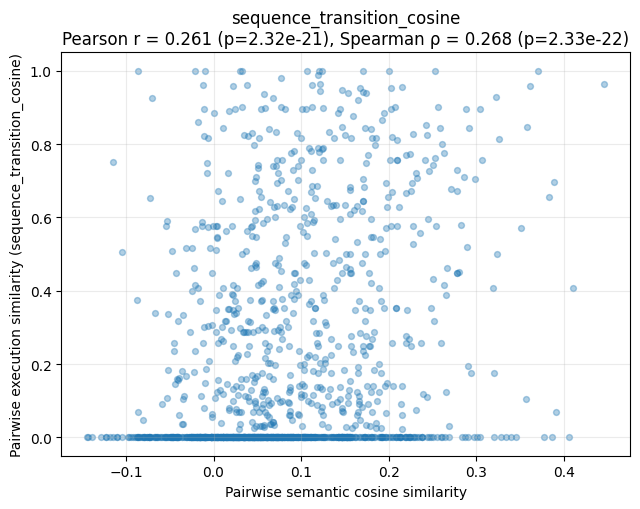

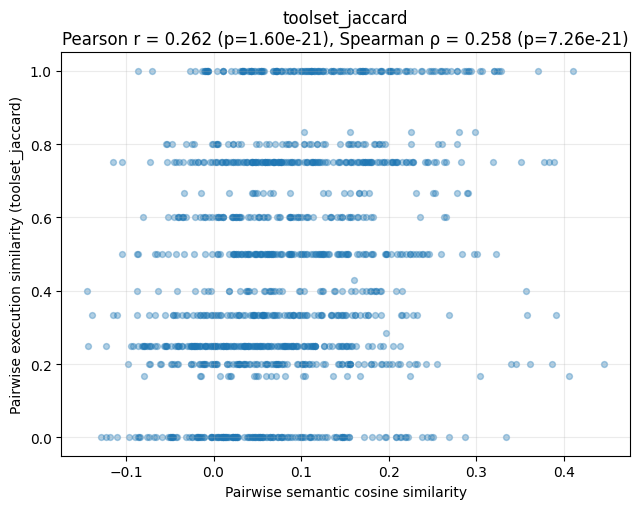

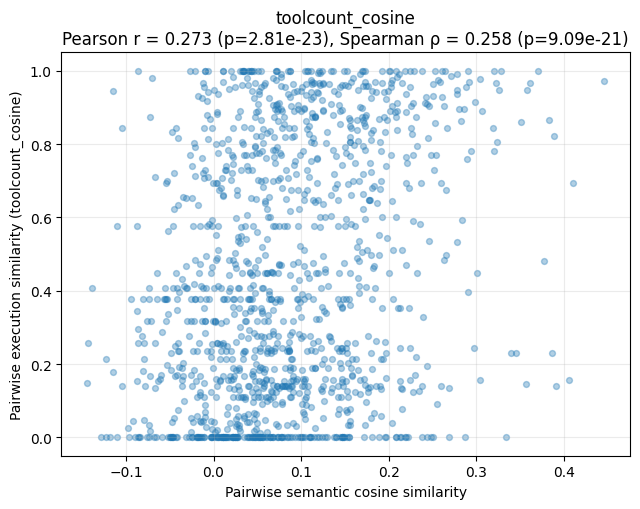

In [24]:
# ============================================================
# Scatter plots: semantic similarity vs execution similarity
# Top-3 strongest metrics:
#   1) sequence_transition_cosine
#   2) toolset_jaccard
#   3) toolcount_cosine
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# Helper: extract upper triangle (exclude diagonal)
# ------------------------------------------------------------
def upper_triangle_values(M):
    idx = np.triu_indices_from(M, k=1)
    return M[idx]

# ------------------------------------------------------------
# Semantic similarity values (x-axis for all three plots)
# ------------------------------------------------------------
x_sem = upper_triangle_values(S_sem)

# ------------------------------------------------------------
# Metric list
# ------------------------------------------------------------
scatter_specs = [
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolset_jaccard", S_exec_toolset_jaccard),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

# ------------------------------------------------------------
# Make one separate figure per metric
# ------------------------------------------------------------
for metric_name, M_exec in scatter_specs:
    y_exec = upper_triangle_values(M_exec)

    pearson_r, pearson_p = pearsonr(x_sem, y_exec)
    spearman_rho, spearman_p = spearmanr(x_sem, y_exec)

    plt.figure(figsize=(6.5, 5.2))
    plt.scatter(x_sem, y_exec, alpha=0.35, s=18)

    plt.xlabel("Pairwise semantic cosine similarity")
    plt.ylabel(f"Pairwise execution similarity ({metric_name})")
    plt.title(
        f"{metric_name}\n"
        f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e}), "
        f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})"
    )

    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

- pairwise: 51x50/2=1275 points
- toolset_jaccard is discrete, so it forms horizontal bands
- toolcount_cosine and transition cosine often produce many values near 0 because some pairs have almost no overlap
- A correlation around 0.25 means the relation exists, but not visually clear in a raw scatter plot.

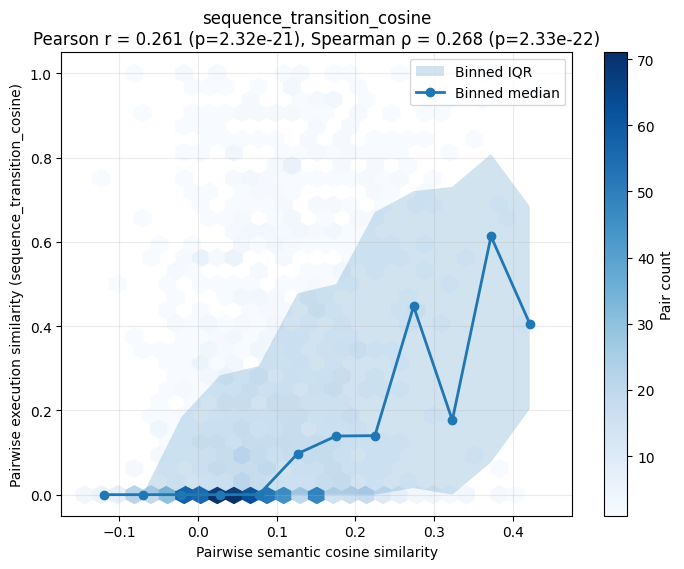

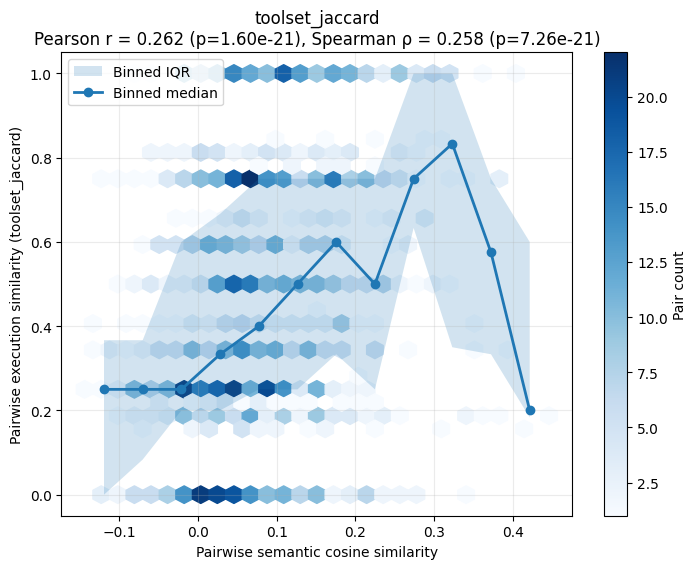

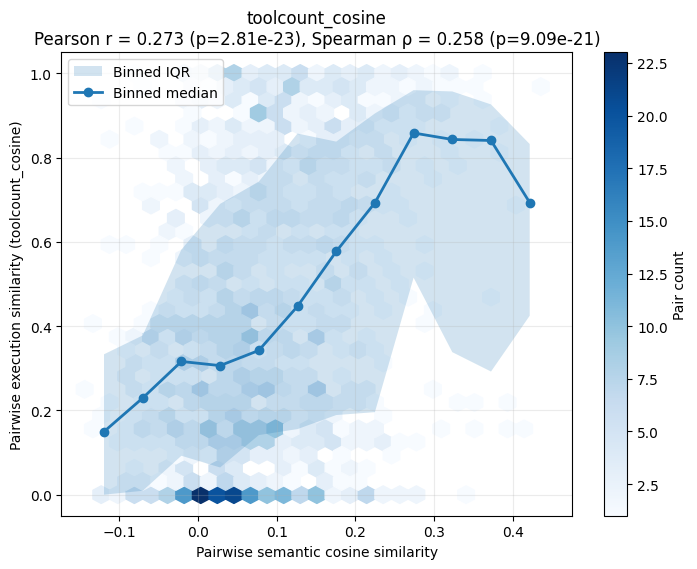

In [26]:
# ============================================================
# Hexbin + binned median trend for top-3 execution metrics
#   1) sequence_transition_cosine
#   2) toolset_jaccard
#   3) toolcount_cosine
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def upper_triangle_values(M):
    idx = np.triu_indices_from(M, k=1)
    return M[idx]

def compute_binned_stats(x, y, n_bins=12):
    """
    Bin x, then compute per-bin:
      - center
      - count
      - median(y)
      - q25(y)
      - q75(y)
    """
    x = np.asarray(x)
    y = np.asarray(y)

    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]

    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    medians = np.full(n_bins, np.nan, dtype=np.float64)
    q25 = np.full(n_bins, np.nan, dtype=np.float64)
    q75 = np.full(n_bins, np.nan, dtype=np.float64)
    counts = np.zeros(n_bins, dtype=int)

    # include right edge in last bin
    bin_ids = np.digitize(x, edges[1:-1], right=False)

    for b in range(n_bins):
        mask = (bin_ids == b)
        yb = y[mask]
        counts[b] = int(mask.sum())
        if len(yb) > 0:
            medians[b] = np.median(yb)
            q25[b] = np.percentile(yb, 25)
            q75[b] = np.percentile(yb, 75)

    return {
        "edges": edges,
        "centers": centers,
        "counts": counts,
        "median": medians,
        "q25": q25,
        "q75": q75,
    }

# ------------------------------------------------------------
# Semantic similarity on x-axis
# ------------------------------------------------------------
x_sem = upper_triangle_values(S_sem)

# ------------------------------------------------------------
# Metrics to plot
# ------------------------------------------------------------
plot_specs = [
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolset_jaccard", S_exec_toolset_jaccard),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

# ------------------------------------------------------------
# Plot one figure per metric
# ------------------------------------------------------------
N_BINS = 12
GRIDSIZE = 28
MINCNT = 1

for metric_name, M_exec in plot_specs:
    y_exec = upper_triangle_values(M_exec)

    pearson_r, pearson_p = pearsonr(x_sem, y_exec)
    spearman_rho, spearman_p = spearmanr(x_sem, y_exec)

    stats = compute_binned_stats(x_sem, y_exec, n_bins=N_BINS)
    centers = stats["centers"]
    medians = stats["median"]
    q25 = stats["q25"]
    q75 = stats["q75"]
    counts = stats["counts"]

    valid = np.isfinite(medians)

    fig, ax = plt.subplots(figsize=(7.2, 5.8))

    hb = ax.hexbin(
        x_sem,
        y_exec,
        gridsize=GRIDSIZE,
        mincnt=MINCNT,
        cmap="Blues",
    )
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Pair count")

    # IQR band
    if np.any(valid):
        ax.fill_between(
            centers[valid],
            q25[valid],
            q75[valid],
            alpha=0.20,
            label="Binned IQR",
        )

        # median trend
        ax.plot(
            centers[valid],
            medians[valid],
            marker="o",
            linewidth=2.0,
            label="Binned median",
        )

    # annotate counts lightly above the plot if useful
    # (comment out if too busy)
    # for xc, yc, c in zip(centers[valid], medians[valid], counts[valid]):
    #     ax.text(xc, yc + 0.03, str(c), ha="center", va="bottom", fontsize=8, alpha=0.8)

    ax.set_xlabel("Pairwise semantic cosine similarity")
    ax.set_ylabel(f"Pairwise execution similarity ({metric_name})")
    ax.set_title(
        f"{metric_name}\n"
        f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e}), "
        f"Spearman ρ = {spearman_rho:.3f} (p={spearman_p:.2e})"
    )
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

Why hexbin figures looks much cleaner
- Hexbin: summarize local point density
- Instead of drawing every point individually, the plane is divided into many small hexagonal cells.
- Can be regarded as turning a noisy scatter cloud into a **2D histogram**.

Neighborhood vs random summary


,metric_name,top_k,n_queries,mean_semantic_neighbor_exec_sim,mean_random_neighbor_exec_sim,mean_delta,median_delta,fraction_queries_semantic_beats_random,wilcoxon_stat,wilcoxon_p_one_sided
0,toolcount_cosine,3,51,0.647841,0.441646,0.206196,0.195492,0.843137,1151.0,3.580261e-07
1,toolset_jaccard,3,51,0.642810,0.470745,0.172066,0.190944,0.803922,1125.0,1.263288e-06
2,sequence_transition_cosine,3,51,0.359013,0.208958,0.150055,0.100108,0.607843,732.0,7.520137e-06


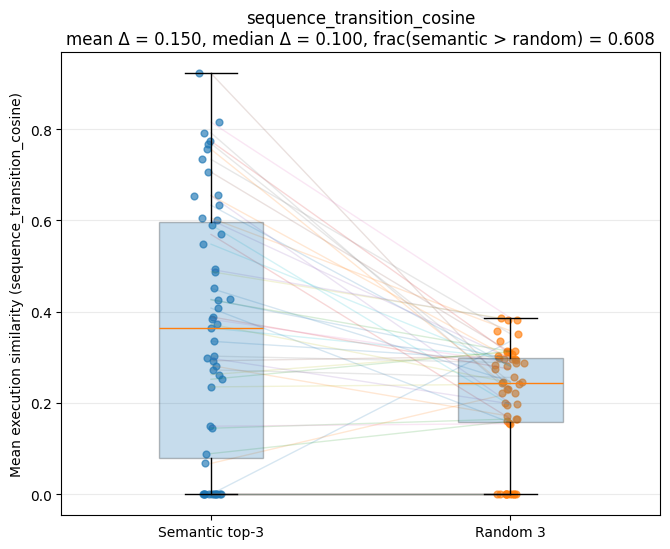

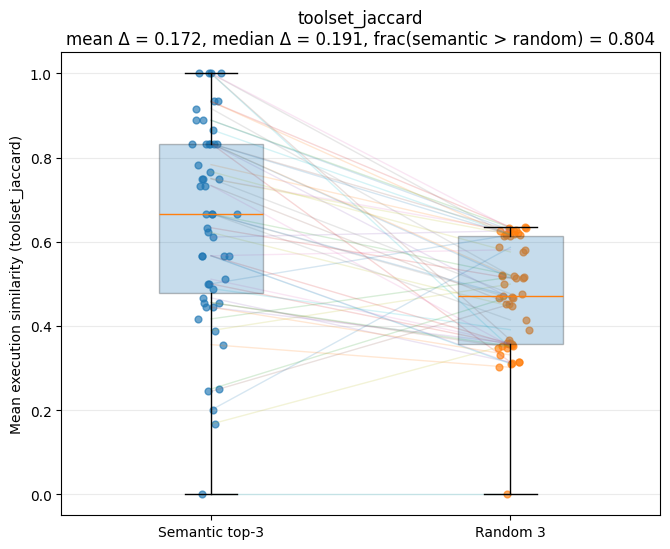

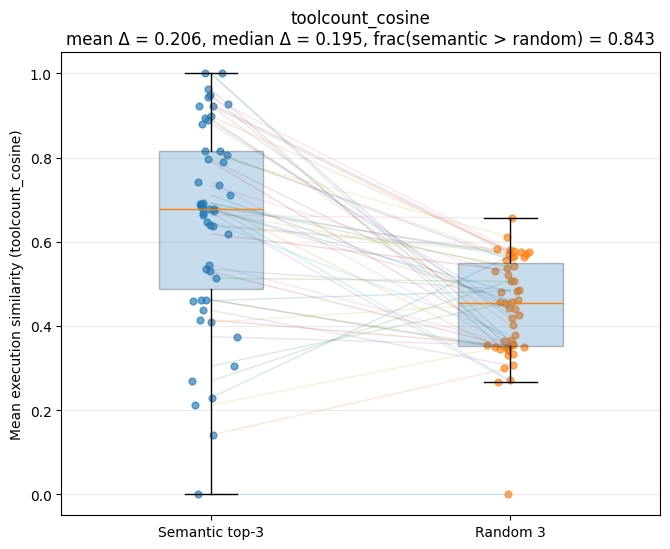

In [27]:
# ============================================================
# Neighborhood vs random comparison
# For each query:
#   - find top-k semantic neighbors
#   - compute mean execution similarity to those neighbors
#   - compare against mean execution similarity to random neighbors
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
TOP_K = 3
N_RANDOM_TRIALS = 1000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def topk_semantic_neighbors(S_sem, k):
    """
    For each query i, return indices of top-k semantic neighbors excluding self.
    """
    n = S_sem.shape[0]
    nbrs = []
    for i in range(n):
        order = np.argsort(-S_sem[i])   # descending similarity
        order = [j for j in order if j != i]
        nbrs.append(order[:k])
    return nbrs

def random_neighbor_means(sim_matrix, k=3, n_trials=1000, seed=42):
    """
    For each query i, repeatedly sample k random non-self neighbors.
    Return mean across trials for each query.
    """
    rng_local = np.random.default_rng(seed)
    n = sim_matrix.shape[0]
    out = np.zeros(n, dtype=np.float64)

    for i in range(n):
        candidates = np.array([j for j in range(n) if j != i], dtype=int)
        vals = []

        for _ in range(n_trials):
            chosen = rng_local.choice(candidates, size=k, replace=False)
            vals.append(np.mean(sim_matrix[i, chosen]))

        out[i] = float(np.mean(vals))
    return out

def semantic_neighbor_means(sim_matrix, semantic_neighbors):
    """
    For each query i, average execution similarity to its semantic top-k neighbors.
    """
    n = sim_matrix.shape[0]
    out = np.zeros(n, dtype=np.float64)

    for i in range(n):
        nbrs = semantic_neighbors[i]
        out[i] = float(np.mean(sim_matrix[i, nbrs]))
    return out

# ------------------------------------------------------------
# Semantic neighbors from S_sem
# ------------------------------------------------------------
semantic_topk = topk_semantic_neighbors(S_sem, k=TOP_K)

# ------------------------------------------------------------
# Metrics to compare
# ------------------------------------------------------------
metric_specs = [
    ("sequence_transition_cosine", S_exec_seq_transition_cosine),
    ("toolset_jaccard", S_exec_toolset_jaccard),
    ("toolcount_cosine", S_exec_toolcount_cosine),
]

# ------------------------------------------------------------
# Compute summary table
# ------------------------------------------------------------
rows = []
per_metric_details = {}

for metric_name, S_exec in metric_specs:
    semantic_means = semantic_neighbor_means(S_exec, semantic_topk)
    random_means = random_neighbor_means(
        S_exec,
        k=TOP_K,
        n_trials=N_RANDOM_TRIALS,
        seed=RANDOM_SEED,
    )
    deltas = semantic_means - random_means

    # one-sided Wilcoxon: semantic_means > random_means
    # scipy returns a result object; method/alternative supported in recent scipy
    try:
        w = wilcoxon(
            semantic_means,
            random_means,
            alternative="greater",
            zero_method="wilcox",
        )
        wilcoxon_stat = float(w.statistic)
        wilcoxon_p = float(w.pvalue)
    except Exception:
        wilcoxon_stat = np.nan
        wilcoxon_p = np.nan

    rows.append({
        "metric_name": metric_name,
        "top_k": TOP_K,
        "n_queries": len(semantic_means),
        "mean_semantic_neighbor_exec_sim": float(np.mean(semantic_means)),
        "mean_random_neighbor_exec_sim": float(np.mean(random_means)),
        "mean_delta": float(np.mean(deltas)),
        "median_delta": float(np.median(deltas)),
        "fraction_queries_semantic_beats_random": float(np.mean(deltas > 0)),
        "wilcoxon_stat": wilcoxon_stat,
        "wilcoxon_p_one_sided": wilcoxon_p,
    })

    per_metric_details[metric_name] = {
        "semantic_means": semantic_means,
        "random_means": random_means,
        "deltas": deltas,
    }

df_neighbor_vs_random = pd.DataFrame(rows).sort_values(
    by="mean_delta",
    ascending=False
).reset_index(drop=True)

print("Neighborhood vs random summary")
display(df_neighbor_vs_random)

# ------------------------------------------------------------
# Plot paired comparison for each metric
# ------------------------------------------------------------
for metric_name, _ in metric_specs:
    semantic_means = per_metric_details[metric_name]["semantic_means"]
    random_means = per_metric_details[metric_name]["random_means"]
    deltas = per_metric_details[metric_name]["deltas"]

    fig, ax = plt.subplots(figsize=(6.8, 5.6))

    x1 = np.full_like(semantic_means, 0, dtype=np.float64)
    x2 = np.full_like(random_means, 1, dtype=np.float64)

    # small horizontal jitter for readability
    jitter1 = rng.normal(0, 0.03, size=len(x1))
    jitter2 = rng.normal(0, 0.03, size=len(x2))

    # paired lines
    for i in range(len(semantic_means)):
        ax.plot(
            [0, 1],
            [semantic_means[i], random_means[i]],
            alpha=0.18,
            linewidth=1.0,
        )

    # points
    ax.scatter(x1 + jitter1, semantic_means, alpha=0.65, s=24, label="Semantic top-k")
    ax.scatter(x2 + jitter2, random_means, alpha=0.65, s=24, label="Random k")

    # boxplots on top
    bp = ax.boxplot(
        [semantic_means, random_means],
        positions=[0, 1],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
    )
    for patch in bp["boxes"]:
        patch.set_alpha(0.25)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"Semantic top-{TOP_K}", f"Random {TOP_K}"])
    ax.set_ylabel(f"Mean execution similarity ({metric_name})")
    ax.set_title(
        f"{metric_name}\n"
        f"mean Δ = {np.mean(deltas):.3f}, "
        f"median Δ = {np.median(deltas):.3f}, "
        f"frac(semantic > random) = {np.mean(deltas > 0):.3f}"
    )
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

How the figures are plotted
- 1) for each anchor query i, ind its top-3 semantic neighbors
- 2) look up the execution similarity between the anchor and each of those 3 neighbors
- 3) average those 3 anchor-to-neighbor execution similarities

Then for the random baseline, for the same anchor i
- 1) sample 3 random other queries
- 2) compute and average the their execution similarities
- 3) repeat step 1 and 2 many times
- 4) average those trial means

- The median line rises quite steadily as semantic similarity increases.
- i.e., query pairs that are more semantically similar tend to have more similar `tool-sequence`/`tool-set`/`tool-count` profiles
- Support the same message as the quantitative correlations: the relationship is not tight but there is a clear tendency (by observing the median)

Why semantic top-3 has much higher variance than random 3
- Because it is random and then averaged, it tends to stay near the global average execution similarity.

Quick conclusion
- The mean is higher
- The median is higher
- But the variance is high
- It implies predicting `tool-sequence`/`tool-set`/`tool-count` using semantic similarity sometimes works extremely well, sometimes ... may not be useful
- But such a prediction should still be overall better than random 

UMAP coordinates shape: (51, 2)


,query_id,query_text,umap_color_score_toolset,umap_color_score_toolcount,umap_color_score_sequence
0,23dd907f-1261-4488-b21c-e9185af91d5e,In Audre Lorde’s poem “Father Son and Holy Gho...,0.911137,1.237693,1.708915
1,3f57289b-8c60-48be-bd80-01f8099ca449,How many at bats did the Yankee with the most ...,0.911137,-0.070293,-0.055653
2,46719c30-f4c3-4cad-be07-d5cb21eee6bb,Of the authors (First M. Last) that worked on ...,0.911137,1.528684,1.783762
3,50ec8903-b81f-4257-9450-1085afd2c319,A standard Rubik’s cube has been broken into c...,-1.461037,-1.116706,-0.826026
4,5cfb274c-0207-4aa7-9575-6ac0bd95d9b2,Each cell in the attached spreadsheet represen...,-1.160993,-0.177623,-0.050151


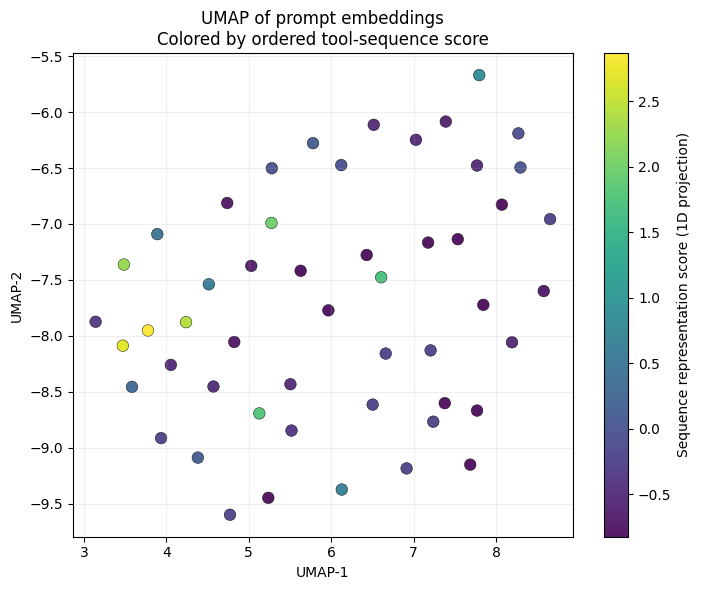

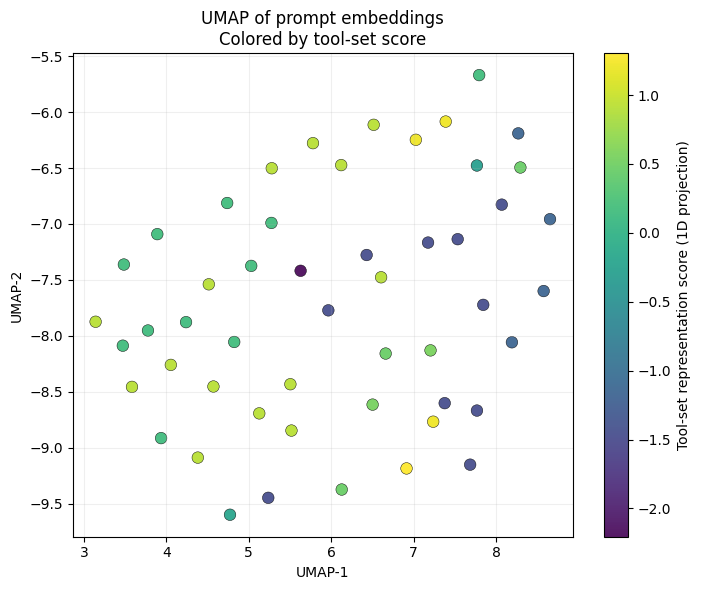

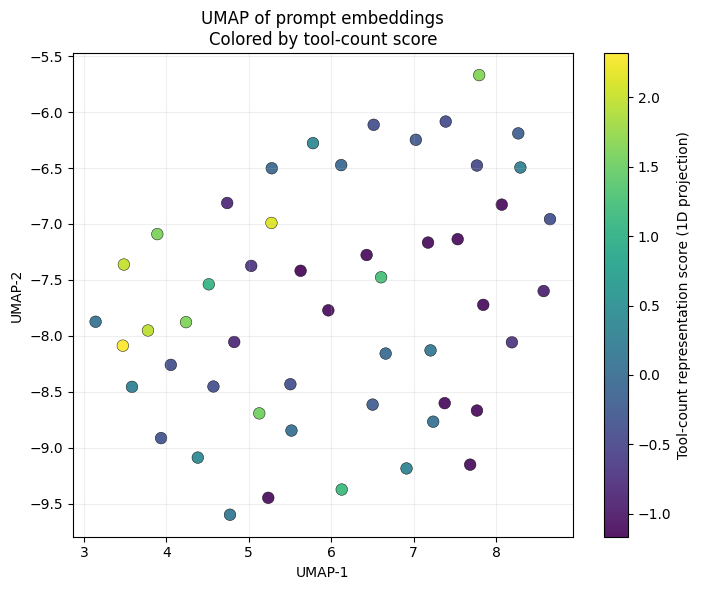

In [30]:
# ============================================================
# UMAP of prompt embeddings, colored by execution representation
# Three plots:
#   1) colored by tool-set 1D score
#   2) colored by tool-count 1D score
#   3) colored by ordered tool-sequence 1D score
#
# IMPORTANT:
# Each execution representation is high-dimensional, so we reduce it
# to a 1D score (first SVD component) for coloring.
# Similar colors mean "similar along the dominant execution axis",
# not exact equality of tool-set / tool-count / tool-sequence.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# UMAP on prompt embeddings
# ------------------------------------------------------------
try:
    import umap.umap_ as umap
except Exception as e:
    raise ImportError(
        "UMAP is not available. Install with `pip install umap-learn`."
    ) from e

umap_model = umap.UMAP(
    n_neighbors=10,
    min_dist=0.20,
    metric="cosine",
    random_state=42,
)

X_umap = umap_model.fit_transform(X_embed)

print("UMAP coordinates shape:", X_umap.shape)

# ------------------------------------------------------------
# Helper: 1D projection score for coloring
# ------------------------------------------------------------
def first_component_score(X, name="X"):
    """
    Reduce a feature matrix X (n_samples, n_features) to a single
    continuous score using the first TruncatedSVD component.
    Then z-score it for easier color interpretation.
    """
    X = np.asarray(X, dtype=np.float32)

    if X.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape={X.shape}")

    if X.shape[1] == 0:
        raise ValueError(f"{name} has zero columns.")

    if X.shape[1] == 1:
        score = X[:, 0].astype(np.float32)
    else:
        svd = TruncatedSVD(n_components=1, random_state=42)
        score = svd.fit_transform(X).reshape(-1).astype(np.float32)

    # z-score for a centered colormap
    mu = float(np.mean(score))
    sigma = float(np.std(score))
    if sigma == 0:
        sigma = 1.0
    score_z = (score - mu) / sigma
    return score_z

# ------------------------------------------------------------
# Build 1D color scores for each execution representation
# Assumes these were already created earlier:
#   X_toolset_binary
#   X_toolcount
#   X_tool_transition
# ------------------------------------------------------------
score_toolset = first_component_score(X_toolset_binary, name="X_toolset_binary")
score_toolcount = first_component_score(X_toolcount, name="X_toolcount")
score_sequence = first_component_score(X_tool_transition, name="X_tool_transition")

# Optional: attach scores to df for inspection
df["umap_color_score_toolset"] = score_toolset
df["umap_color_score_toolcount"] = score_toolcount
df["umap_color_score_sequence"] = score_sequence

display(
    df[
        [
            "query_id",
            "query_text",
            "umap_color_score_toolset",
            "umap_color_score_toolcount",
            "umap_color_score_sequence",
        ]
    ].head()
)

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_umap_colored(X2d, color_values, title, cbar_label):
    plt.figure(figsize=(7.2, 6.0))
    sc = plt.scatter(
        X2d[:, 0],
        X2d[:, 1],
        c=color_values,
        s=70,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.35,
    )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title(title)
    plt.grid(True, alpha=0.20)
    cbar = plt.colorbar(sc)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Three plots
# ------------------------------------------------------------
plot_umap_colored(
    X_umap,
    score_sequence,
    title="UMAP of prompt embeddings\nColored by ordered tool-sequence score",
    cbar_label="Sequence representation score (1D projection)",
)

plot_umap_colored(
    X_umap,
    score_toolset,
    title="UMAP of prompt embeddings\nColored by tool-set score",
    cbar_label="Tool-set representation score (1D projection)",
)

plot_umap_colored(
    X_umap,
    score_toolcount,
    title="UMAP of prompt embeddings\nColored by tool-count score",
    cbar_label="Tool-count representation score (1D projection)",
)

- The point positions come only from the prompt embeddings (UMAP)
- The colors come from the 1D projection of a vector (i.e., tool-sequence/tool-set/tool-count)
- If nearby points tend to have similar colors, that suggests semantic neighborhoods align with similar execution structure

Tool-set clustering model selection:


,k,silhouette_cosine,inertia
0,4,0.546648,5.250547
1,5,0.574471,4.075173
2,6,0.649799,3.285122


Tool-count clustering model selection:


,k,silhouette_cosine,inertia
0,4,0.667582,5.128803
1,5,0.627219,4.298864
2,6,0.689744,3.471975


Tool-sequence clustering model selection:


,k,silhouette_cosine,inertia
0,4,0.380625,12.118724
1,5,0.433759,9.759956
2,6,0.433354,8.173171


Chosen k for tool-set      : 6  | silhouette=0.6498
Chosen k for tool-count    : 6 | silhouette=0.6897
Chosen k for tool-sequence : 5  | silhouette=0.4338


,query_id,query_text,exec_cluster_toolset,exec_cluster_toolcount,exec_cluster_toolseq
0,23dd907f-1261-4488-b21c-e9185af91d5e,In Audre Lorde’s poem “Father Son and Holy Gho...,2,1,0
1,3f57289b-8c60-48be-bd80-01f8099ca449,How many at bats did the Yankee with the most ...,2,3,4
2,46719c30-f4c3-4cad-be07-d5cb21eee6bb,Of the authors (First M. Last) that worked on ...,2,1,0
3,50ec8903-b81f-4257-9450-1085afd2c319,A standard Rubik’s cube has been broken into c...,3,2,1
4,5cfb274c-0207-4aa7-9575-6ac0bd95d9b2,Each cell in the attached spreadsheet represen...,1,0,3
5,65afbc8a-89ca-4ad5-8d62-355bb401f61d,You are given this Excel file as a map. You st...,4,0,3
6,72e110e7-464c-453c-a309-90a95aed6538,Under DDC 633 on Bielefeld University Library'...,2,1,0
7,7673d772-ef80-4f0f-a602-1bf4485c9b43,On Cornell Law School website's legal informat...,5,1,0
8,7bd855d8-463d-4ed5-93ca-5fe35145f733,The attached Excel file contains the sales of ...,4,0,3
9,9318445f-fe6a-4e1b-acbf-c68228c9906a,"As a comma separated list with no whitespace, ...",4,0,3


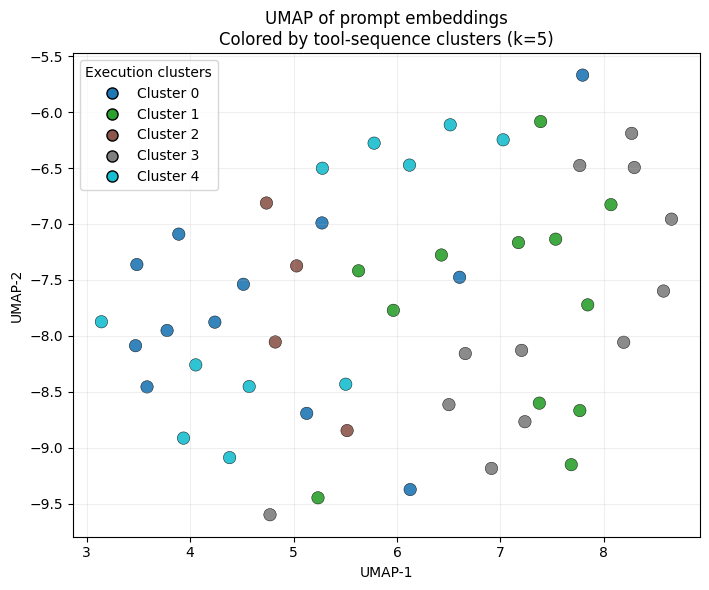

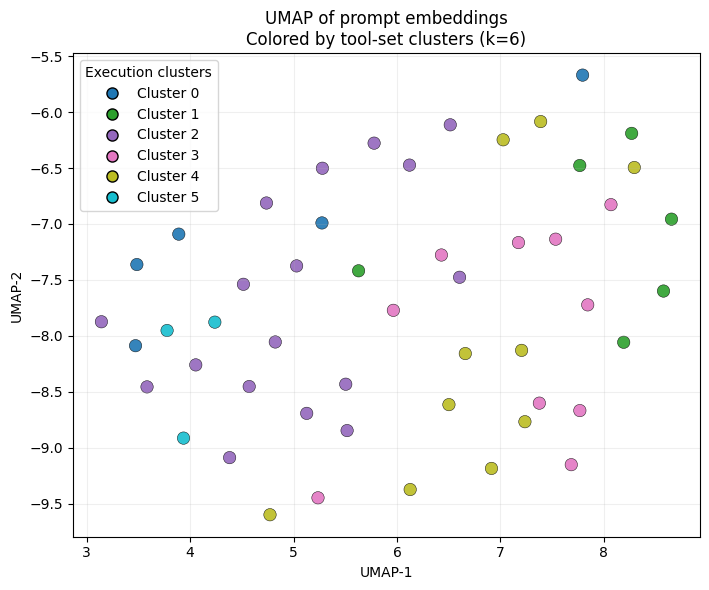

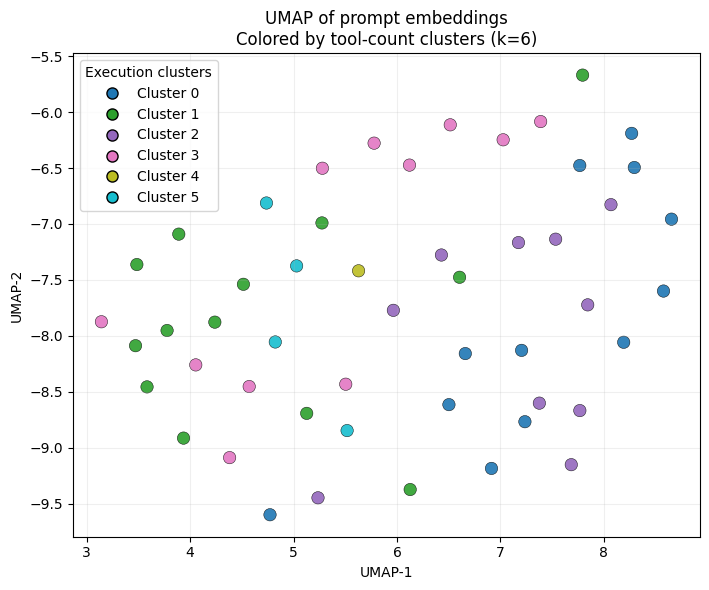

In [32]:
# ============================================================
# UMAP of prompt embeddings, colored by EXECUTION CLUSTER LABELS
#
# Uses the SAME UMAP coordinates X_umap computed from prompt embeddings.
# Clusters are computed separately for:
#   1) tool-set representation      -> X_toolset_binary
#   2) tool-count representation    -> X_toolcount
#   3) tool-sequence representation -> X_tool_transition
#
# Cluster IDs are categorical labels only; they have no ordinal meaning.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
required_arrays = {
    "X_umap": "UMAP coordinates from prompt embeddings",
    "X_toolset_binary": "binary tool-set feature matrix",
    "X_toolcount": "tool-count feature matrix",
    "X_tool_transition": "tool-transition feature matrix",
}

missing = [name for name in required_arrays if name not in globals()]
if missing:
    raise ValueError(
        "Missing required objects: "
        + ", ".join(f"{m} ({required_arrays[m]})" for m in missing)
    )

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def row_l2_normalize(X):
    """
    Row-normalize a dense matrix. Safe for zero rows.
    """
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

def choose_best_kmeans_k(X, k_min=2, k_max=6, random_state=42):
    """
    Choose k by silhouette score.
    Uses Euclidean KMeans on row-normalized vectors.
    Evaluates clustering quality with cosine silhouette.
    """
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]

    # cannot have k >= n
    k_max = min(k_max, n - 1)
    if k_min > k_max:
        raise ValueError(f"Invalid k range after clipping: k_min={k_min}, k_max={k_max}")

    results = []
    best = None

    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X)

        # silhouette requires at least 2 clusters and not all singleton issues
        if len(np.unique(labels)) < 2:
            sil = -1.0
        else:
            try:
                sil = silhouette_score(X, labels, metric="cosine")
            except Exception:
                sil = -1.0

        row = {
            "k": k,
            "silhouette_cosine": float(sil),
            "inertia": float(km.inertia_),
            "labels": labels,
            "model": km,
        }
        results.append(row)

        if best is None or row["silhouette_cosine"] > best["silhouette_cosine"]:
            best = row

    results_df = pd.DataFrame(
        [{k: v for k, v in r.items() if k not in {"labels", "model"}} for r in results]
    ).sort_values("k").reset_index(drop=True)

    return best, results_df

def plot_umap_with_cluster_labels(X2d, labels, title):
    """
    Scatter UMAP coordinates with discrete cluster coloring.
    """
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)

    # map arbitrary labels to 0..C-1 for stable coloring
    label_map = {lab: i for i, lab in enumerate(sorted(unique_labels))}
    color_ids = np.array([label_map[lab] for lab in labels], dtype=int)

    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")

    fig, ax = plt.subplots(figsize=(7.2, 6.0))
    sc = ax.scatter(
        X2d[:, 0],
        X2d[:, 1],
        c=color_ids,
        cmap=cmap,
        s=80,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.35,
    )

    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_title(title)
    ax.grid(True, alpha=0.20)

    # discrete legend
    handles = []
    texts = []
    for lab in sorted(unique_labels):
        cid = label_map[lab]
        handles.append(
            plt.Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markerfacecolor=cmap(cid / max(1, n_clusters - 1)),
                markeredgecolor="black",
                markersize=8,
            )
        )
        texts.append(f"Cluster {lab}")

    ax.legend(handles, texts, title="Execution clusters", loc="best", frameon=True)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Prepare normalized execution feature matrices
# ------------------------------------------------------------
X_toolset_norm = row_l2_normalize(X_toolset_binary)
X_toolcount_norm = row_l2_normalize(X_toolcount)
X_toolseq_norm = row_l2_normalize(X_tool_transition)

# ------------------------------------------------------------
# Cluster each execution representation
# ------------------------------------------------------------
best_toolset, df_k_toolset = choose_best_kmeans_k(X_toolset_norm, k_min=4, k_max=6, random_state=42)
best_toolcount, df_k_toolcount = choose_best_kmeans_k(X_toolcount_norm, k_min=4, k_max=6, random_state=42)
best_toolseq, df_k_toolseq = choose_best_kmeans_k(X_toolseq_norm, k_min=4, k_max=6, random_state=42)

print("Tool-set clustering model selection:")
display(df_k_toolset)

print("Tool-count clustering model selection:")
display(df_k_toolcount)

print("Tool-sequence clustering model selection:")
display(df_k_toolseq)

labels_toolset = best_toolset["labels"]
labels_toolcount = best_toolcount["labels"]
labels_toolseq = best_toolseq["labels"]

print(f"Chosen k for tool-set      : {best_toolset['k']}  | silhouette={best_toolset['silhouette_cosine']:.4f}")
print(f"Chosen k for tool-count    : {best_toolcount['k']} | silhouette={best_toolcount['silhouette_cosine']:.4f}")
print(f"Chosen k for tool-sequence : {best_toolseq['k']}  | silhouette={best_toolseq['silhouette_cosine']:.4f}")

# ------------------------------------------------------------
# Optional: attach labels to df for inspection
# ------------------------------------------------------------
df["exec_cluster_toolset"] = labels_toolset
df["exec_cluster_toolcount"] = labels_toolcount
df["exec_cluster_toolseq"] = labels_toolseq

display(
    df[
        [
            "query_id",
            "query_text",
            "exec_cluster_toolset",
            "exec_cluster_toolcount",
            "exec_cluster_toolseq",
        ]
    ].head(10)
)

# ------------------------------------------------------------
# Plot the SAME prompt-embedding UMAP coordinates, colored by
# different execution cluster labels
# ------------------------------------------------------------
plot_umap_with_cluster_labels(
    X_umap,
    labels_toolseq,
    title=(
        "UMAP of prompt embeddings\n"
        f"Colored by tool-sequence clusters (k={best_toolset['k'] if False else best_toolseq['k']})"
    ),
)

plot_umap_with_cluster_labels(
    X_umap,
    labels_toolset,
    title=(
        "UMAP of prompt embeddings\n"
        f"Colored by tool-set clusters (k={best_toolset['k']})"
    ),
)

plot_umap_with_cluster_labels(
    X_umap,
    labels_toolcount,
    title=(
        "UMAP of prompt embeddings\n"
        f"Colored by tool-count clusters (k={best_toolcount['k']})"
    ),
)

- Modification: 
    - keep the same UMAP coordinates from the prompt embeddings
    - cluster each execution representation separately
    - color each point by its cluster ID instead of a continuous scalar
- Do nearby semantic points tend to share the same execution cluster label?